# Faster R-CNN Training for Parking-Slot Occupancy Detection

This notebook trains a **PyTorch Faster R-CNN** model to detect and classify parking spaces as **empty** or **occupied**.

It is written for the dataset layout already present in this project:

- `data/train`
- `data/valid`
- `data/test`
- one COCO annotation file per split: `_annotations.coco.json`

The notebook covers the full workflow:

- reading only the first `N` images and matching annotations from each split
- converting images and targets into tensors with `Dataset` and `DataLoader`
- CUDA-aware training and validation loops
- saving checkpoints and loss history
- plotting and storing loss curves
- running inference on sample images and visualizing predictions

The dataset categories in this export are:

- `1 -> space-empty`
- `2 -> space-occupied`


In [1]:
import csv
import json
import math
import os
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_MobileNet_V3_Large_FPN_Weights
from torchvision.transforms import functional as TF


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = DEVICE.type == 'cuda'

ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / 'data'
CHECKPOINT_DIR = ROOT_DIR / 'checkpoints'
MODEL_DIR = ROOT_DIR / 'models'
CURVE_DIR = ROOT_DIR / 'losses_curves'

for directory in [CHECKPOINT_DIR, MODEL_DIR, CURVE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CLASS_ID_TO_NAME = {
    1: 'space-empty',
    2: 'space-occupied',
}
NUM_CLASSES = 3  # background + 2 foreground classes

print(f'Device: {DEVICE}')
print(f'AMP enabled: {AMP_ENABLED}')
# print(f'Project root: {ROOT_DIR.resolve()}')


Device: cuda
AMP enabled: True


## 1. Read COCO annotations and optionally keep only the first `N` images per split

The helper utilities below do four things:

1. read a split-level COCO annotation file,
2. keep only images that physically exist inside the split folder,
3. optionally keep only the first `N` images for faster experimentation,
4. return image records plus only the annotations that belong to those images.

This notebook is intentionally configured for **subset training**. It reads only the first `N` images from each split so you can train faster without using the full dataset.

In [2]:
def load_coco_split(split_dir: Path):
    annotation_path = split_dir / '_annotations.coco.json'
    with open(annotation_path, 'r', encoding='utf-8') as f:
        coco = json.load(f)
    return coco


def build_annotation_map(annotations):
    ann_map = defaultdict(list)
    for ann in annotations:
        ann_map[ann['image_id']].append(ann)
    return ann_map


def collect_split_records(data_dir: Path, split: str, limit: int | None = None):
    split_dir = data_dir / split
    coco = load_coco_split(split_dir)

    available_files = {p.name for p in split_dir.glob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}}
    images = [img for img in coco['images'] if img['file_name'] in available_files]

    if limit is not None:
        images = images[:limit]

    selected_ids = {img['id'] for img in images}
    annotations = [ann for ann in coco['annotations'] if ann['image_id'] in selected_ids and ann['category_id'] in CLASS_ID_TO_NAME]
    ann_map = build_annotation_map(annotations)

    records = []
    for img in tqdm(images, desc=f'Collecting {split} records', leave=False):
        image_path = split_dir / img['file_name']
        records.append({
            'split': split,
            'image_id': img['id'],
            'file_name': img['file_name'],
            'image_path': image_path,
            'width': img['width'],
            'height': img['height'],
            'annotations': ann_map.get(img['id'], []),
        })
    return records, coco


def summarize_records(records_by_split):
    print('Dataset summary')
    print('-' * 90)
    header = f"{'Split':<10}{'Images':>10}{'Boxes':>12}{'Empty':>12}{'Occupied':>14}"
    print(header)
    print('-' * 90)

    for split, records in records_by_split.items():
        class_counter = Counter()
        total_boxes = 0
        for record in records:
            for ann in record['annotations']:
                class_counter[ann['category_id']] += 1
                total_boxes += 1

        print(
            f"{split:<10}{len(records):>10}{total_boxes:>12}{class_counter[1]:>12}{class_counter[2]:>14}"
        )


SPLIT_LIMITS = {
    'train': 100,
    'valid': 20,
    'test': 20,
}

records_by_split = {}
coco_by_split = {}
for split_name in tqdm(['train', 'valid', 'test'], desc='Loading dataset splits'):
    split_records, split_coco = collect_split_records(DATA_DIR, split_name, limit=SPLIT_LIMITS[split_name])
    records_by_split[split_name] = split_records
    coco_by_split[split_name] = split_coco

summarize_records(records_by_split)

for split_name, records in records_by_split.items():
    first_record = records[0]
    print(f'First sample from {split_name}:')
    print(f"  file_name: {first_record['file_name']}")
    # print(f"  image_abs_path: {first_record['image_path'].resolve()}")
    print(f"  image_id: {first_record['image_id']}")
    print(f"  annotation_count: {len(first_record['annotations'])}")
    print()


Loading dataset splits:   0%|          | 0/3 [00:00<?, ?it/s]

Dataset summary
------------------------------------------------------------------------------------------
Split         Images       Boxes       Empty      Occupied
------------------------------------------------------------------------------------------
train            100        6556        3541          3015
valid             20        1352         704           648
test              20        1256         610           646
First sample from train:
  file_name: 2013-04-10_12_00_06_jpg.rf.bef78f7879666a6d8997ce513fd8d124.jpg
  image_id: 0
  annotation_count: 40

First sample from valid:
  file_name: 2012-12-21_18_10_14_jpg.rf.62e89081eb0427cd3a372345b23ed409.jpg
  image_id: 0
  annotation_count: 28

First sample from test:
  file_name: 2012-11-06_13_43_31_jpg.rf.00207754dbce0d625d24ca31898fcfd7.jpg
  image_id: 0
  annotation_count: 100



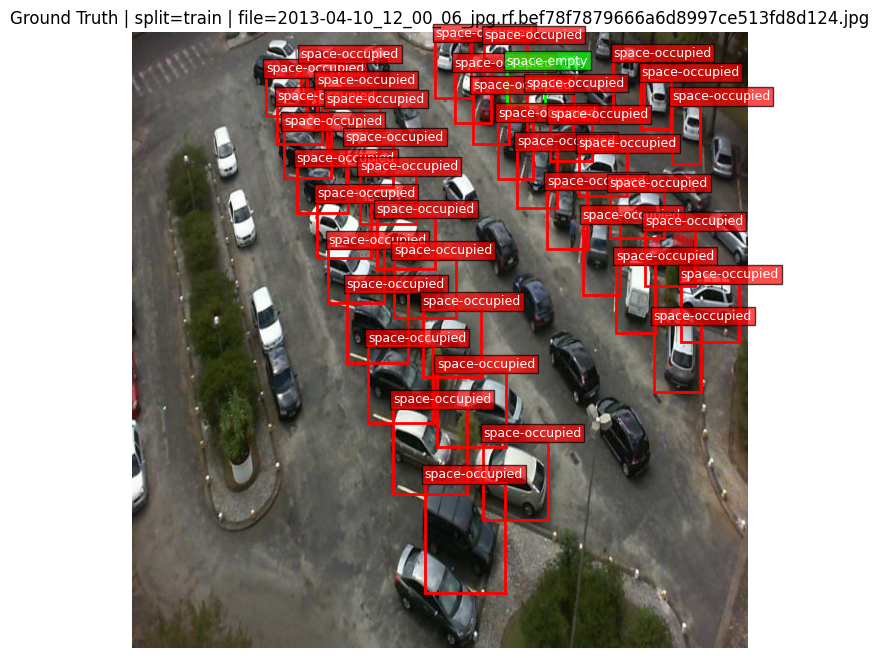

In [3]:
def show_ground_truth_sample(records, index=0, figsize=(8, 8)):
    record = records[index]
    image = Image.open(record['image_path']).convert('RGB')

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(image)

    colors = {
        1: 'lime',
        2: 'red',
    }

    for ann in record['annotations']:
        x, y, w, h = ann['bbox']
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2,
            edgecolor=colors.get(ann['category_id'], 'yellow'),
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x,
            max(0, y - 5),
            CLASS_ID_TO_NAME[ann['category_id']],
            color='white',
            fontsize=9,
            bbox=dict(facecolor=colors.get(ann['category_id'], 'black'), alpha=0.7, pad=2)
        )

    ax.set_title(f"Ground Truth | split={record['split']} | file={record['file_name']}")
    ax.axis('off')
    plt.show()


show_ground_truth_sample(records_by_split['train'], index=0)


## 2. Convert images and annotations into tensors with `Dataset` and `DataLoader`

For object detection, each image can have a different number of bounding boxes. That means we use:

- a custom `Dataset` that returns `(image_tensor, target_dict)`
- a custom `collate_fn` so the dataloader keeps images and targets as Python lists

The training transform includes a synchronized horizontal flip that updates bounding boxes as well.

In [4]:
class ParkingSpacesDataset(Dataset):
    def __init__(self, records, train=False):
        self.records = records
        self.train = train

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        image = Image.open(record['image_path']).convert('RGB')
        width, height = image.size

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in record['annotations']:
            x, y, w, h = ann['bbox']
            x1 = max(0, x)
            y1 = max(0, y)
            x2 = min(width, x + w)
            y2 = min(height, y + h)

            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2, y2])
            labels.append(int(ann['category_id']))
            areas.append(float((x2 - x1) * (y2 - y1)))
            iscrowd.append(int(ann.get('iscrowd', 0)))

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)

        if self.train and torch.rand(1).item() < 0.5:
            image = TF.hflip(image)
            if boxes.numel() > 0:
                x1 = boxes[:, 0].clone()
                x2 = boxes[:, 2].clone()
                boxes[:, 0] = width - x2
                boxes[:, 2] = width - x1

        image_tensor = TF.to_tensor(image)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([record['image_id']], dtype=torch.int64),
            'area': areas,
            'iscrowd': iscrowd,
            'split': record['split'],
            'file_name': record['file_name'],
        }
        return image_tensor, target


def detection_collate_fn(batch):
    return tuple(zip(*batch))


def make_dataloader(dataset, batch_size, shuffle, num_workers=2):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=(DEVICE.type == 'cuda'),
        persistent_workers=(num_workers > 0),
        collate_fn=detection_collate_fn,
    )


train_dataset = ParkingSpacesDataset(records_by_split['train'], train=True)
valid_dataset = ParkingSpacesDataset(records_by_split['valid'], train=False)
test_dataset = ParkingSpacesDataset(records_by_split['test'], train=False)

# Windows + Jupyter is usually much more stable with num_workers=0 for detection training.
BATCH_SIZE = 1
NUM_WORKERS = 0

train_loader = make_dataloader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
valid_loader = make_dataloader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = make_dataloader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


# Keep it off unless you want to sanity-check one batch.
INSPECT_FIRST_BATCH = False

if INSPECT_FIRST_BATCH:
    sample_images, sample_targets = next(iter(train_loader))
    print(f'Number of images in one training batch: {len(sample_images)}')
    print(f'Shape of first image tensor: {sample_images[0].shape}')
    print(f'Keys inside target dict: {sample_targets[0].keys()}')
    print(f'First target labels sample: {sample_targets[0]["labels"][:10]}')


## 3. Build The Model

This cell only does setup.

- builds the Faster R-CNN model with a MobileNetV3 backbone
- replaces the classifier head for 3 classes
- freezes the backbone and creates the optimizer, scheduler, and AMP scaler
- defines one training function and one validation function

This cell does **not** start training.

The **next cell** is the one that actually starts training for **5 epochs** on the **200-image training subset**.

In [5]:
def move_targets_to_device(targets, device):
    moved = []
    for target in targets:
        moved_target = {}
        for key, value in target.items():
            if torch.is_tensor(value):
                moved_target[key] = value.to(device, non_blocking=True)
            else:
                moved_target[key] = value
        moved.append(moved_target)
    return moved


weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights, min_size=320)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

model.rpn.pre_nms_top_n_train = 1000
model.rpn.post_nms_top_n_train = 200
model.rpn.pre_nms_top_n_test = 500
model.rpn.post_nms_top_n_test = 100

for param in model.backbone.parameters():
    param.requires_grad = False

model = model.to(DEVICE)

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
scaler = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)

print(model.__class__.__name__)


def train_one_epoch(model, dataloader, optimizer, device, scaler, epoch_idx):
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(enumerate(dataloader, start=1), total=len(dataloader), desc=f'Train Epoch {epoch_idx}', leave=False)
    for batch_idx, (images, targets) in progress_bar:
        images = [img.to(device, non_blocking=True) for img in images]
        targets = move_targets_to_device(targets, device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda', enabled=AMP_ENABLED):
            loss_dict = model(images, targets)
            total_loss = sum(loss for loss in loss_dict.values())

        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_value = total_loss.detach().item()
        running_loss += loss_value

        progress_bar.set_postfix(train_loss=f'{loss_value:.4f}')

    epoch_loss = running_loss / max(1, len(dataloader))
    return epoch_loss


def validate_one_epoch(model, dataloader, device):
    model.train()
    running_loss = 0.0

    with torch.no_grad():
        progress_bar = tqdm(dataloader, total=len(dataloader), desc='Validation', leave=False)
        for images, targets in progress_bar:
            images = [img.to(device, non_blocking=True) for img in images]
            targets = move_targets_to_device(targets, device)

            with torch.amp.autocast(device_type='cuda', enabled=AMP_ENABLED):
                loss_dict = model(images, targets)
                total_loss = sum(loss for loss in loss_dict.values())

            loss_value = total_loss.detach().item()
            running_loss += loss_value
            progress_bar.set_postfix(val_loss=f'{loss_value:.4f}')

    epoch_loss = running_loss / max(1, len(dataloader))
    model.eval()
    return epoch_loss


FasterRCNN


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Train Epoch 1:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/5 | train_loss=1.4993


Train Epoch 2:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 2/5 | train_loss=1.0988


...

Epoch 3/5 | train_loss=1.0622


Train Epoch 4:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 4/5 | train_loss=1.0178


Train Epoch 5:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 5/5 | train_loss=0.9995


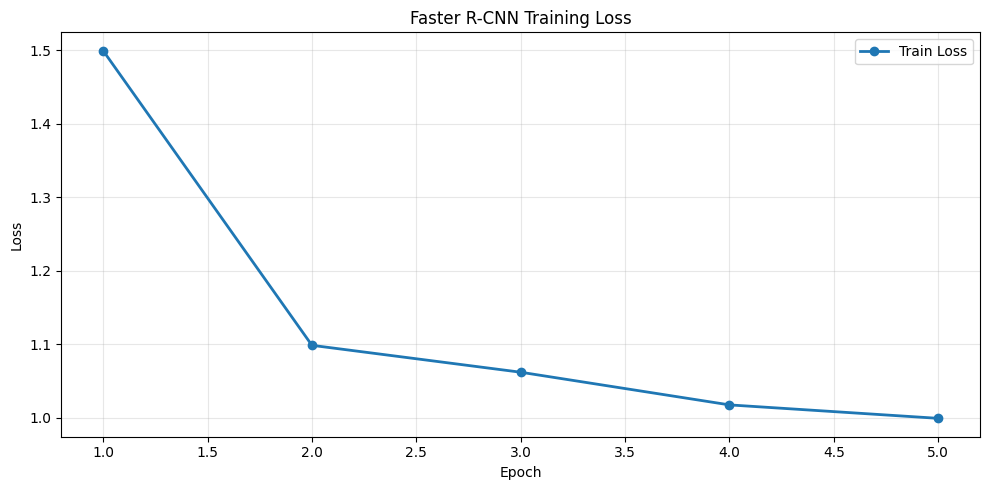

In [6]:
def plot_loss_curves(history, save_path=None, title='Faster R-CNN Training Loss'):
    if len(history) == 0:
        print('History is empty. Train the model first.')
        return

    epochs = [row['epoch'] for row in history]
    train_losses = [row['train_loss'] for row in history]
    val_losses = [row['val_loss'] for row in history if 'val_loss' in row]

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, marker='o', linewidth=2, label='Train Loss')
    if len(val_losses) == len(epochs) and len(val_losses) > 0:
        plt.plot(epochs, val_losses, marker='s', linewidth=2, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        # print(f'Loss curve saved to: {Path(save_path).resolve()}')
    plt.show()


NUM_EPOCHS = 5
history = []

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc='Epochs'):
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE, scaler, epoch)
    scheduler.step()

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
    })

    print(f'Epoch {epoch}/{NUM_EPOCHS} | train_loss={train_loss:.4f}')
    torch.save(model.state_dict(), MODEL_DIR / 'fasterrcnn_parking_debug_fast.pt')

plot_loss_curves(history, save_path=CURVE_DIR / 'fasterrcnn_parking_debug_fast_loss_curve.png')


## 4. Load the best checkpoint and run inference on sample images

The next helpers make it easy to:

- load saved weights,
- run inference on one image or a dataset sample,
- threshold predictions by confidence,
- visualize predicted empty and occupied spaces.

This is useful both for validation-time inspection and for final testing on held-out images.

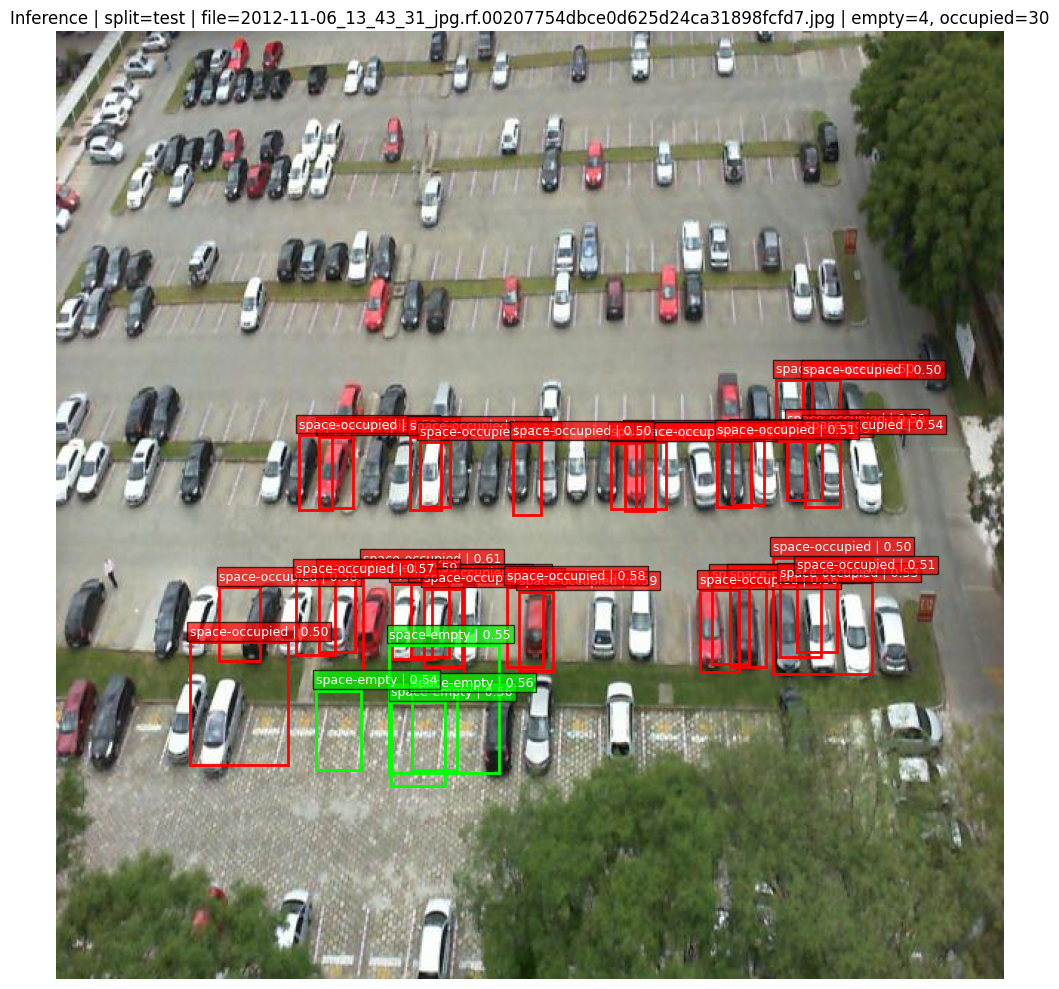

({'split': 'test',
  'image_id': 0,
  'file_name': '2012-11-06_13_43_31_jpg.rf.00207754dbce0d625d24ca31898fcfd7.jpg',
  'image_path': WindowsPath('c:/Users/tRiX/Documents/cv_projects/mask_rcnn/faster_rcnn/data/test/2012-11-06_13_43_31_jpg.rf.00207754dbce0d625d24ca31898fcfd7.jpg'),
  'width': 640,
  'height': 640,
  'annotations': [{'id': 0,
    'image_id': 0,
    'category_id': 1,
    'bbox': [139, 165, 23, 40],
    'area': 920,
    'segmentation': [],
    'iscrowd': 0},
   {'id': 1,
    'image_id': 0,
    'category_id': 1,
    'bbox': [155, 165, 22.5, 42.5],
    'area': 956.25,
    'segmentation': [],
    'iscrowd': 0},
   {'id': 2,
    'image_id': 0,
    'category_id': 1,
    'bbox': [172, 165, 21.5, 42.5],
    'area': 913.75,
    'segmentation': [],
    'iscrowd': 0},
   {'id': 3,
    'image_id': 0,
    'category_id': 1,
    'bbox': [188, 164, 23, 42.5],
    'area': 977.5,
    'segmentation': [],
    'iscrowd': 0},
   {'id': 4,
    'image_id': 0,
    'category_id': 1,
    'bbox': [2

In [11]:
def load_model_weights(model, weight_path, device):
    state_dict = torch.load(weight_path, map_location=device)
    if isinstance(state_dict, dict) and 'model_state_dict' in state_dict:
        state_dict = state_dict['model_state_dict']
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


def run_inference(model, image_path, device, score_threshold=0.5):
    image = Image.open(image_path).convert('RGB')
    image_tensor = TF.to_tensor(image).to(device)

    model.eval()
    with torch.no_grad():
        prediction = model([image_tensor])[0]

    scores = prediction['scores'].detach().cpu().numpy()
    keep = scores >= score_threshold

    filtered = {
        'boxes': prediction['boxes'].detach().cpu().numpy()[keep],
        'labels': prediction['labels'].detach().cpu().numpy()[keep],
        'scores': scores[keep],
    }
    return image, filtered


def visualize_predictions(image, prediction, figsize=(10, 10), save_path=None, title='Predictions'):
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(image)

    colors = {
        1: 'lime',
        2: 'red',
    }

    for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor=colors.get(int(label), 'yellow'),
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            max(0, y1 - 5),
            f"{CLASS_ID_TO_NAME.get(int(label), 'unknown')} | {score:.2f}",
            color='white',
            fontsize=9,
            bbox=dict(facecolor=colors.get(int(label), 'black'), alpha=0.7, pad=2)
        )

    occupied_count = int(np.sum(prediction['labels'] == 2))
    empty_count = int(np.sum(prediction['labels'] == 1))
    ax.set_title(f"{title} | empty={empty_count}, occupied={occupied_count}")
    ax.axis('off')
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        # print(f'Prediction plot saved to: {Path(save_path).resolve()}')
    plt.show()


def evaluate_dataset_sample(model, dataset, index=0, score_threshold=0.5, save_path=None):
    record = dataset.records[index]
    image, prediction = run_inference(model, record['image_path'], DEVICE, score_threshold=score_threshold)
    visualize_predictions(
        image,
        prediction,
        title=f"Inference | split={record['split']} | file={record['file_name']}",
        save_path=save_path,
    )
    return record, prediction



inference_model = fasterrcnn_mobilenet_v3_large_fpn(weights=None, min_size=320)
in_features = inference_model.roi_heads.box_predictor.cls_score.in_features
inference_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
inference_model.rpn.pre_nms_top_n_train = 1000
inference_model.rpn.post_nms_top_n_train = 200
inference_model.rpn.pre_nms_top_n_test = 500
inference_model.rpn.post_nms_top_n_test = 100
inference_model = load_model_weights(inference_model, MODEL_DIR / 'fasterrcnn_parking.pt', DEVICE)
evaluate_dataset_sample(
    inference_model,
    test_dataset,
    index=0,
    score_threshold=0.5,
    save_path=CURVE_DIR / 'fasterrcnn_test_prediction_0.png'
)


## 5. Suggested workflow

Use this order when you run the notebook:

1. Pick the subset size you want in `SPLIT_LIMITS`.
2. Run one or two epochs first to confirm the pipeline works on your GPU.
3. Train on that subset for more epochs.
4. Plot the loss curves and inspect test predictions.

Reasonable first settings for subset training:

- `BATCH_SIZE = 2` or `4` depending on GPU memory
- `NUM_EPOCHS = 10` for an initial run
- `score_threshold = 0.5` for visual inspection

If CUDA memory becomes tight, reduce:

- `BATCH_SIZE`
- subset size in `SPLIT_LIMITS`
- number of workers if your system becomes unstable

This notebook is intentionally verbose so you can expand it later with metrics such as mAP, confusion analysis, or class-wise occupancy counting, while still training only on a manageable subset.